In [1]:
#imported from Pranav Sanghavi's notebook 
import glob 
import os 
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
import math
import psutil
import matplotlib.cm as cm
from scipy.stats import iqr
import pytz,pickle,yaml,sys
from scipy.optimize import curve_fit
#importing for Will's extract_source_pulses function 
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable

#import the beamcals module, use forked repository (not original):
#sys.path.insert(0, '../../classes/')
#import corr, concat, drone
#import plotting_utils as pu
#import fitting_utils as fu
#import geometry_utils as gu
import time_utils as tu
#import site_utils as si
#gbosite=si.Site('../../metadata/TONE_d5_config.npz')
#gbosite=si.Site('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/TONE_d5_config.npz')


style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()
        
def chunk_lists_(data_):
    """
        This function makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """
    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:
                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])
            else:
                yield consecutive_list
                consecutive_list = []        
        except Exception:
            pass   
    yield consecutive_list
    
def split_into_small_lists(big_lists, small_size=4, long_threshold=11, n_chunks=3, min_len=2):
    """
        This function splits the sublists of time indices of individual ON/OFF pulses into 3/4-element lists
        Returns list of lists
        - ≤11 elements: chunk into small_size
        - ≤2 elements: throw away the list 
    """
    small_chunks = []
    for list1 in big_lists:
        if len(list1) <= long_threshold:
            small_groups = [list1[i:i + small_size] for i in range(0, len(list1), small_size)]
        small_chunks.extend(small_groups)
    return [group for group in small_chunks if len(group) >= min_len]  # Drop empties if any


In [ ]:
from matplotlib import colormaps
list(colormaps)

Calculating digital gains of the channels...


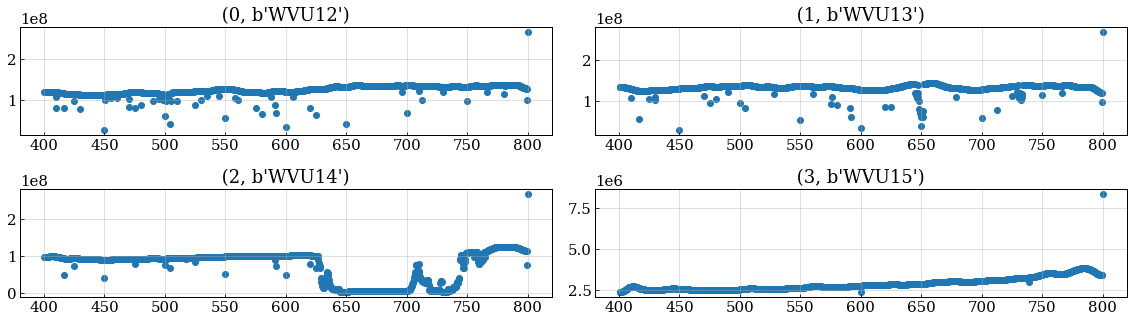

In [2]:
#Reading digital gains -- 
f = h5py.File("/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/digital_gains/20250412T191307Z_WVUc52_digitalgain/00000056.h5","r")

#Plotting digital gains -- 
inputs = (f['index_map']['input'][:])
frqs = f['index_map']['freq'][:]
gaincoeff = f['gain_coeff'][()]
gainexp = f['gain_exp'][()]
gain = gaincoeff.real*np.exp2(gainexp)

plt.figure(figsize=[16,18])
print(f"Calculating digital gains of the channels...")
i = 0
for i in np.arange(0,4,1):  
    plt.subplot(8,2,i+1)
    #Digital gain of every channel
    plt.scatter(frqs['centre'], gain[0][:,i]) # i referes to input channel (total 16 ch on iceboard); 
    #plt.title( " %s and gain_exp = %s and rms %s for rms i/p %s" %(inputs[i], gainexp[:,i], rms[i][2], rms[i][0][2]))
    plt.title( " %s " %(inputs[i]))
plt.tight_layout()

In [3]:
## 2.5m/s single pass 
## -- correlator data 
# reading the required only corr files for plotting beam pattern
file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/*/*'

# reading files for main beam pass 
corr_data = read_corr_mode_h5(file_path, f_start=101, f_stop=104)
pow_mag, pow_phase = get_mag_phase(corr_data.vis)

Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0101
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0101
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0102
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0102
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0103
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_ra

In [201]:

"""
    WTyndall's function imported for fitting ON and OFF pulse points 
"""

def Extract_Source_Pulses_pub(self,f_ind):
    #If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        pow_mag, pow_phase = get_mag_phase(self.vis)
        Period=0.9998e6
        Dutycycle=0.5e6
        t_bounds=[0,-1]
        minmaxpercents=[0.0001,100]
        #Create Switch Signal:
        self.pulse_period=Period
        self.pulse_dutycycle=Dutycycle
        delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
        concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
        time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        #Create t_offset range (1 period) and Pearson_r vars:
        t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)# 1ms steps 
        #n_channels = 10 # for GBO
        n_channels = 3 # for Yale 
        #channel_indices = [0,1,2,3,4,5,6,7,8,9] # for GBO
        channel_indices = [7,8,9] # for Yale 
        Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
        Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
        Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
        #Given parameters:
        num_bins = len(pow_mag[:,f_ind,9]) # 9 for yale; 9 in N2 matrix is ref channel
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_full = np.arange(num_bins) * time_bin_width

    
        ## Loop over channels to find/plot a time offset solution with some clever fitting:
        fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
        for i, ch_index in enumerate(channel_indices):
            ## Finding a baseline power level that’s almost the minimum, subtract it from the signal 
            ## so that ‘background’ power becomes zero before normalization.”
            minsubdata=self.vis[:,f_ind,ch_index]-np.percentile(self.vis[:,f_ind,ch_index],minmaxpercents[0])
            ## make all channels have the same range (0–1), so the Pearson correlation step later isn’t skewed by power differences.
            normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
            ## clipping ensures baseline stays at 0 and maximum stays at 1 
            ## makes it directly comparable to our ideal square wave (0 = OFF, 1 = ON) 
            ## so Pearson correlation can find the best alignment.
            clipnormminsubdata=normminsubdata.clip(0,1)
            ## turns your cleaned signal into a function you can call at any time point,
            ## holding each sample’s value until the next one, so you can match it directly 
            ## to the ideal pulse pattern.
            stepped_func=interpolate.interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
            
            sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
            t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)

            ##Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
            for j,t_offset in enumerate(t_offset_dist):
                shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                try:
                    Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
                except ValueError:
                    Pr_arr[i,j]=np.NAN
                    print(str(j)+" failed: " +str(t_offset))
            
            ax1.plot(t_offset_dist,Pr_arr[i,:],'*',label=str(i))
           
            try:
                maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
                ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
                Pr_max_ind_per_channel[i]=maxPrind
                Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
            except IndexError:
                Pr_max_ind_per_channel[i]=np.NAN
                Pr_max_t_0_per_channel[i]=np.NAN
                
        # Always considering reference channel for fitting (time offset from ref) as anyways switching is in sync 
        # Always point this index to the ref channel 
        #self.t_delta_pulse=Pr_max_t_0_per_channel[9]  # for GBO
        self.t_delta_pulse=Pr_max_t_0_per_channel[2]  # for Yale 
        ax1.axvline(self.t_delta_pulse,label="selected t_offset")
        ax1.legend(loc=1)
        plt.tight_layout()
        print("Maximum Pearson_R Correlations between data and square wave function:")
        print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
        print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
        print("Selecting square wave function time offset:")
        print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))

        
        
        t_arr_datetime = t_full 
        #Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        #print(switch_interp_f)
        
        #Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
                                  np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
        self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
 
        ## Each of these lists of indices should also have no overlap. Let's print to see:
        print("Finding relevant pulsing indices and checking for overlaps:")
        print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
        print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
        print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

        #Making subsets of on and off indices for individual ON/OFFs: 
        indon_list=list(chunk_lists_(self.inds_on))
        indoff_list=list(chunk_lists_(self.inds_off))
        #Calculating stats for individual ON/OFF pulses:
        #channel_indices = [0,1,2,3,4,5,6,7,8,9] # for GBO
        channel_indices = [7,8,9] #for Yale 
        
        fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        for i,channel_index in enumerate(channel_indices):
            print("Frequency bin: "+str(f_ind))
            all_data = pow_mag[:,f_ind,channel_index]
            
            ax=fig3.add_subplot(n_channels,1,i+1)
            ax.plot(t_arr_datetime[:],pow_mag[:,f_ind,channel_index],label='data')
            ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
            ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
            ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
            ax.set_ylabel("Log Power Received [$ADU^2$]")
            ax.set_xlabel("Datetime")
            ax.legend(loc=3)
            #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
        # Visualize alignment of switch_interp_f with actual data
        fig_align, ax_align = plt.subplots(figsize=(12, 6))
        #corr33_dat= pow_mag[:,f_ind,3] # for GBO
        corr99_dat= pow_mag[:,f_ind,9] # for Yale 
        #ax_align.plot(t_arr_datetime, corr33_dat, label='Actual Data') # for GBO
        ax_align.plot(t_arr_datetime, corr99_dat, label='Actual Data')
        ax_align.set_xlabel('Datetime')
        ax_align.set_ylabel('Data / Interpolated Switch')
        ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
        ax_align.legend()
        plt.tight_layout()
        plt.show()
        
        return self.inds_on, self.inds_off, self.inds_span

Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [753. 364. 750.]
  --> t_deltas = [-0.247 -0.636 -0.25 ]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.2498000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []
Frequency bin: 315
Frequency bin: 315
Frequency bin: 315


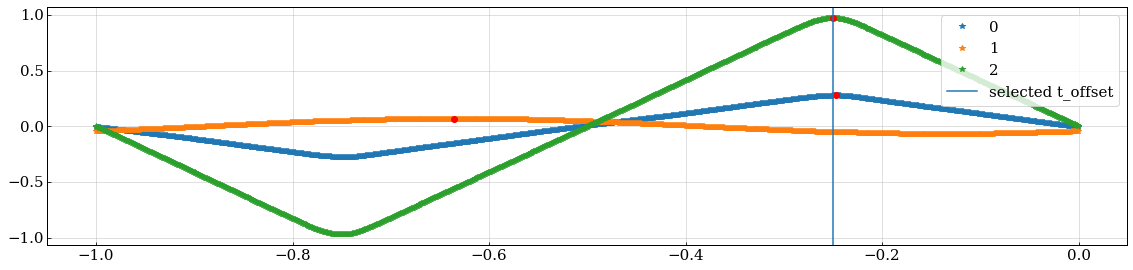

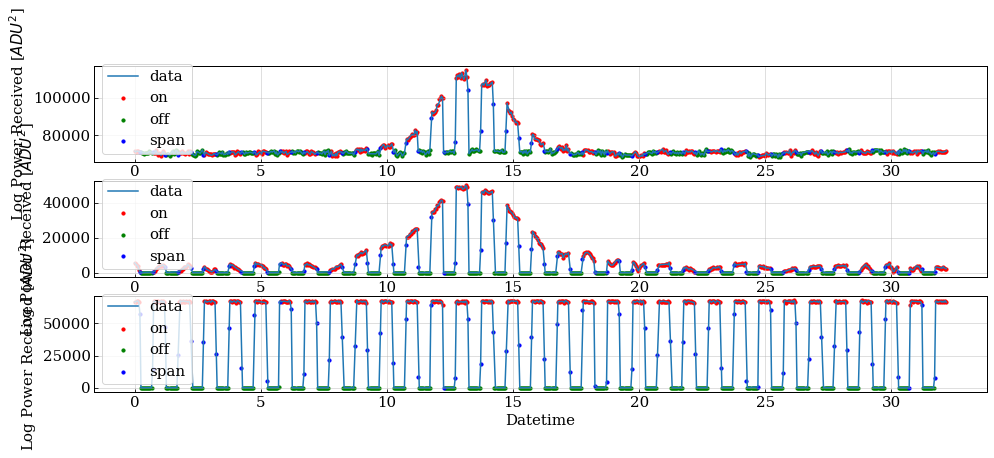

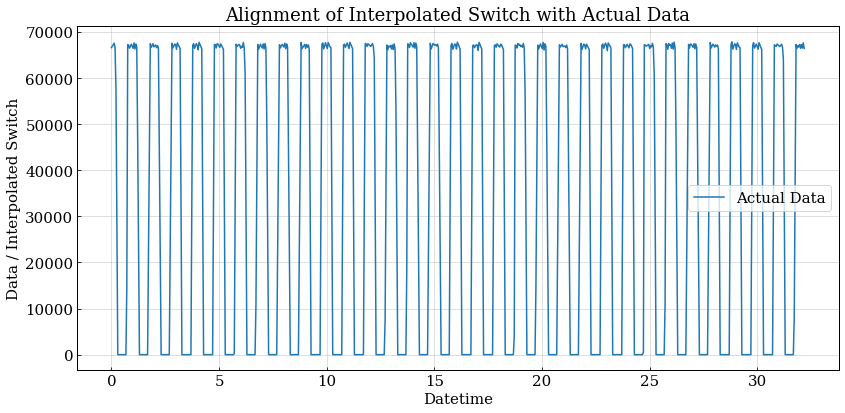

In [205]:

freq_arr=[315]
for index,f_ind in enumerate(freq_arr):
    inds_on, inds_off, inds_span=Extract_Source_Pulses_pub(corr_data,f_ind)


Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 768
lowest time bin 0 and highest time bin 768
32.212254720000004 seconds of data (considered for the plots)


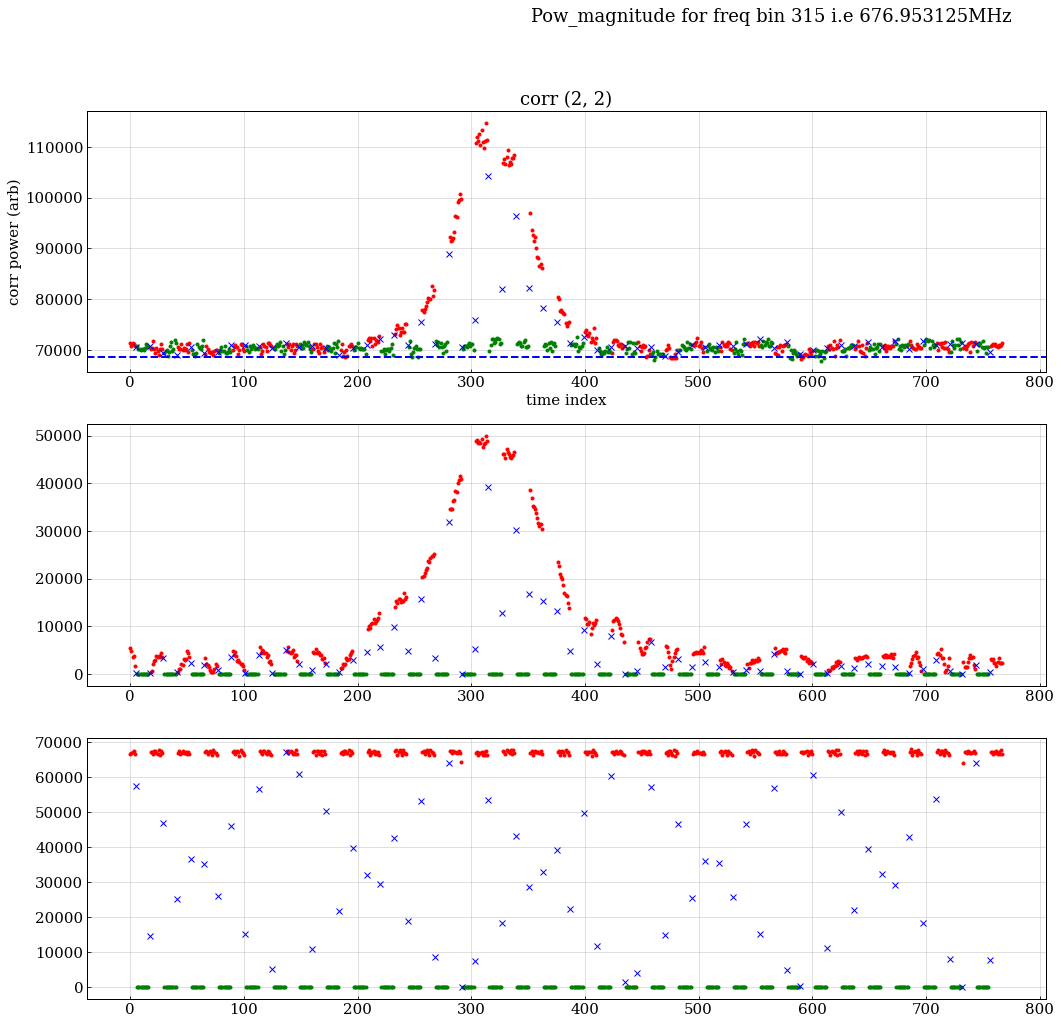

In [206]:
corr_size=corr_data.vis[:,:,:].shape 
tmin,tmax=[0,corr_size[0]]
freq_arr=[315]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[15,15])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(inds_on,pow_mag[inds_on,f_ind,corr_index],'.', c='red', label='abs')
        ax.plot(inds_off,pow_mag[inds_off,f_ind,corr_index],'.', c='green', label='abs')
        ax.plot(inds_span,pow_mag[inds_span,f_ind,corr_index],'x', c='blue', label='abs')
        if corr_index==7:
             plt.axhline(68700, color='b', linestyle='--', linewidth=2)
        else:
            continue
        plt.title(f"corr {corr_data.prod[corr_index]}")
        plt.xlabel("time index")
        plt.ylabel("corr power (arb)")
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

delta_time = np.diff(corr_data.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [207]:
def Perform_Background_Subtraction_Auto(pow_mag,inds_on,inds_off,inds_span,window_size=5):
        ## BACKGROUND SUBTRACTED SPECTRA: ##
        print("Calculating background spectra from indices where the noise source is off.")

        t_index_temp=np.union1d(inds_on, inds_span)
        t_index=np.union1d(t_index_temp,inds_off)
        
        V_bg=np.zeros(pow_mag.shape)
        V_bgsub=np.zeros(pow_mag.shape)
        
        ## Loop over all indices and construct the V_bg array:
        for k,ind in enumerate(t_index):
            ## If ind is an off spectra, use this off spectra for the background:
            if k in inds_off:
                V_bg[k,:,:]=pow_mag[k,:,:]
            ## If ind is an on spectra, create an off spectra by averaging the before/after off spectra:
            elif k in t_index_temp:
                t_window=np.intersect1d(np.arange(k-window_size,k+window_size),inds_off)
                V_bg[k,:,:]=np.nanmean(pow_mag[t_window,:,:],axis=0)
        V_bgsub=pow_mag-V_bg
        print("  --> Background subtraction completed using window_size = {}".format(window_size))
        return V_bgsub

Calculating background spectra from indices where the noise source is off.
  --> Background subtraction completed using window_size = 8
Background subtracted autos shape: (768, 1024, 10)


/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/898288751.py:19: RuntimeWarning: Mean of empty slice
  V_bg[k,:,:]=np.nanmean(pow_mag[t_window,:,:],axis=0)


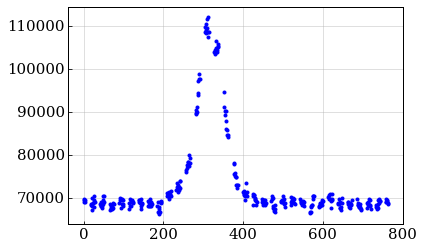

In [208]:
### for drone channel background subtraction
bgsub_powmag=Perform_Background_Subtraction_Auto(pow_mag[:,:,:], inds_on, inds_off, inds_span, window_size=8)
# raising drone auto channels to original background -- 
# possible that it has same raising floor effect on other channels (ignore them for now as we are concerened about only drone autos)
bgsub_powmag=np.add(bgsub_powmag,np.nanmean(pow_mag[inds_off,325,7])) 
#fig = plt.figure(figsize=[15,15])
plt.plot(inds_on,bgsub_powmag[inds_on,315,7], 'b.')
print(f'Background subtracted autos shape: {bgsub_powmag.shape}')

In [209]:
## defining gaussian fit 
def gaussian(x, amp, cen, wid):
    offset=np.median(ydata)
    return offset + amp * np.exp( -(x - cen)**2 / (2 * wid**2) )

Amplitude: 44042.571 ± 381.219
Center: 317.136 ± 0.452
Width (σ): 45.035 ± 0.452


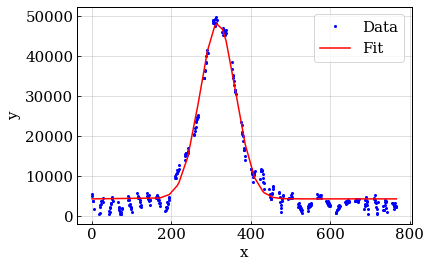

In [210]:
## fitting gaussian data to the data 
f_ind=315
corr_index=8
xdata = inds_on
ydata=pow_mag[inds_on,f_ind,corr_index]

# Initial guess: [amplitude guess, center guess, width guess]
p0 = [max(ydata), xdata[np.argmax(ydata)], 1.0]

# Fit
popt, pcov = curve_fit(gaussian, xdata, ydata, p0=p0)

# Extract params with uncertainties
amp, cen, wid = popt
amp_err, cen_err, wid_err = np.sqrt(np.diag(pcov))

print(f"Amplitude: {amp:.3f} ± {amp_err:.3f}")
print(f"Center: {cen:.3f} ± {cen_err:.3f}")
print(f"Width (σ): {wid:.3f} ± {wid_err:.3f}")

# Plot
plt.plot(xdata, ydata, 'bo', label='Data', markersize=2)
plt.plot(xdata, gaussian(xdata, *popt), 'r-', label='Fit')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.show()


Text(0.5, 0, 'time samples')

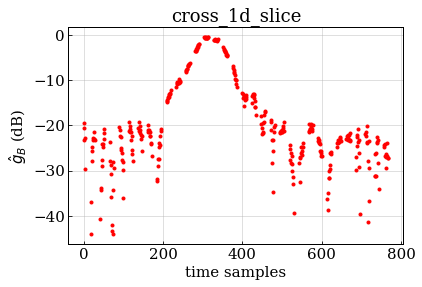

In [211]:
# crosses 1D slice
auto_ref_on=pow_mag[inds_on,f_ind,9]
crosses_on=pow_mag[inds_on,f_ind,8]
crosslog=20*np.log10(crosses_on/np.sqrt(auto_ref_on)) - 46
plt.plot(inds_on,crosslog, 'r.')
plt.title('cross_1d_slice')
plt.ylabel('$\hat{g}_B$ (dB)')
plt.xlabel('time samples')

In [212]:
# for drone autos -- pow_mag becomes bgsub_powmag[:,:,7]
# for crosses -- pow_mag remains the same --> pow_mag[:,:,8]
# for ref autos -- pow_mag remains the same -> pow_mag[:,:,9]

def Calculate_Stats_DroneData(pow_mag,bgsub_powmag,inds_on,inds_off,inds_span,f_ind):
    
    #Making subsets of on and off indices for individual ON/OFFs: 
    indon_list=list(chunk_lists_(inds_on))
    indoff_list=list(chunk_lists_(inds_off))
    #Making small lists from the above chunk lists 
    indon_small = split_into_small_lists(indon_list)
    indoff_small = split_into_small_lists(indoff_list)
    
    channel_indices = [7,8,9]
    on_avgs=[]
    off_avgs=[]
    on_stds=[]
    on_var=[]
    off_var=[]
    
    for i,channel_index in enumerate(channel_indices):
        if channel_index==7:
            all_data = bgsub_powmag[:,f_ind,channel_index]
        else:
            all_data = pow_mag[:,f_ind,channel_index]
        
        avgs_on=[]
        avgs_off=[]
        stds_on=[]
        var_on=[]
        var_off=[]
        for on_list in indon_small:
            avgs_on.append(np.nanmean(all_data[on_list]))
            stds_on.append(np.nanstd(all_data[on_list]))
            var_on.append(np.nanvar(all_data[on_list]))
        for off_list in indoff_small:
            avgs_off.append(np.nanmean(all_data[off_list])) 
            var_off.append(np.nanvar(all_data[off_list]))
            
        on_avgs.append(avgs_on)
        off_avgs.append(avgs_off)
        on_stds.append(stds_on)
        on_var.append(var_on)
        off_var.append(var_off)
        
    return on_avgs, on_stds, off_avgs, on_var, off_var

In [225]:
f_ind=315
on_avgs, on_stds, off_avgs, on_var, off_var=Calculate_Stats_DroneData(pow_mag,bgsub_powmag,inds_on,inds_off,inds_span,f_ind)

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/3942131773.py:33: RuntimeWarning: Mean of empty slice
  avgs_on.append(np.nanmean(all_data[on_list]))
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/3942131773.py:35: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_on.append(np.nanvar(all_data[on_list]))


In [226]:
autos77=np.array(on_avgs[0][:len(off_avgs[0])])
autos99=np.array(on_avgs[2][:len(off_avgs[0])])
crosses79=np.array(on_avgs[1][:len(off_avgs[0])])
var_auto77=np.array(on_var[0][:len(off_avgs[0])])
var_auto99=np.array(on_var[2][:len(off_avgs[0])])
stddev_cross79=np.array(on_stds[1][:len(off_avgs[0])])
autos77_off=np.array(off_avgs[0])
var_auto77_off=np.array(off_var[0])

In [227]:
#Computing std dev for single point and compensated for sims where 4*41.9xxms is int time 
# sqrt of total integration period -- N 65536
stddev_cross7x9=stddev_cross79/2

In [228]:
"""autos7x7 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF
"""
g_autos77 = (autos77 - autos77_off) / autos99

In [229]:
"""
    std dev using error propagation equation -- 
    -- to calculate variance and std dev of g_autos0x0 -- N 65536 
"""
t11 = np.square(1/autos99) 
t21 = np.square(1/autos99) 
t31 = np.square((autos77-autos77_off)/(np.square(autos99))) 

t12=var_auto77 
t22=var_auto77_off 
t32=var_auto99 

t1, t2, t3 = t11*t12, t21*t22, t21*t22

var_gauto77= t1 + t2 + t3 
#std dev for single point and compensated for sims where 4*41.9xxms is int time
stddev_gauto77=np.sqrt(var_gauto77)/2

In [230]:
#Calculating 1-sigma error bars on crosses0x1
yerr_cross_low = []
yerr_cross_high = []
[yerr_cross_low.append(crosses79[i] - (1*stddev_cross7x9[i])) for i in np.arange(0,np.size(stddev_cross7x9))]
[yerr_cross_high.append(crosses79[i] + (1*stddev_cross7x9[i])) for i in np.arange(0,np.size(stddev_cross7x9))]

#Calculating 1-sigma error bars on autos0x0 
yerr_gauto_low = []
yerr_gauto_high = []
[yerr_gauto_low.append(g_autos77[i] - (1*stddev_gauto77[i])) for i in np.arange(0,np.size(stddev_gauto77))]
[yerr_gauto_high.append(g_autos77[i] + (1*stddev_gauto77[i])) for i in np.arange(0,np.size(stddev_gauto77))]


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [231]:
#Calculating 2-sigma error bars on crosses0x1
yerr_cross_low2 = []
yerr_cross_high2 = []
[yerr_cross_low2.append(crosses79[i] - (2*stddev_cross7x9[i])) for i in np.arange(0,np.size(stddev_cross7x9))]
[yerr_cross_high2.append(crosses79[i] + (2*stddev_cross7x9[i])) for i in np.arange(0,np.size(stddev_cross7x9))]

#Calculating 2-sigma error bars on autos0x0 
yerr_gauto_low2 = []
yerr_gauto_high2 = []
[yerr_gauto_low2.append(g_autos77[i] - (2*stddev_gauto77[i])) for i in np.arange(0,np.size(stddev_gauto77))]
[yerr_gauto_high2.append(g_autos77[i] + (2*stddev_gauto77[i])) for i in np.arange(0,np.size(stddev_gauto77))]

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [247]:
## conversion to log scale {normalizing as well}
# dividing factor -- np.sqrt(autos_1x1)

autolog_9x9=10*np.log10(autos99)- 48.3 ## ref ch
crosslog_7x9=20*np.log10(crosses79/np.sqrt(autos99)) - 45.5
autolog_7x7=10*np.log10(autos77) - 50.4 ## test ch
g_autolog_7x7=10*np.log10(g_autos77) + 2.1
autolog_7x7_off=10*np.log10(autos77_off) - 50.4 

## error bars on crosses in log scale 
yerr_cross_lo=20*np.log10(yerr_cross_low/np.sqrt(autos99)) - 45.5
yerr_cross_hi=20*np.log10(yerr_cross_high/np.sqrt(autos99)) - 45.5
yerr_cross_lo2=20*np.log10(yerr_cross_low2/np.sqrt(autos99)) - 45.5
yerr_cross_hi2=20*np.log10(yerr_cross_high2/np.sqrt(autos99)) - 45.5

## error bars on autos0x0 in log scale
yerr_gauto_lo=10*np.log10(yerr_gauto_low) + 2.1
yerr_gauto_hi=10*np.log10(yerr_gauto_high) + 2.1
yerr_gauto_lo2=10*np.log10(yerr_gauto_low2) + 2.1
yerr_gauto_hi2=10*np.log10(yerr_gauto_high2) + 2.1


/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/723642183.py:7: RuntimeWarning: invalid value encountered in log10
  g_autolog_7x7=10*np.log10(g_autos77) + 2.1
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/723642183.py:17: RuntimeWarning: invalid value encountered in log10
  yerr_gauto_lo=10*np.log10(yerr_gauto_low) + 2.1
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/723642183.py:18: RuntimeWarning: invalid value encountered in log10
  yerr_gauto_hi=10*np.log10(yerr_gauto_high) + 2.1
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/723642183.py:19: RuntimeWarning: invalid value encountered in log10
  yerr_gauto_lo2=10*np.log10(yerr_gauto_low2) + 2.1
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/723642183.py:20: RuntimeWarning: invalid value encountered in log10
  yerr_gauto_hi2=10*np.log10(yerr_gauto_high2) + 2.1


In [258]:
yerr_gauto_lo2

array([-18.9061493 , -40.        , -40.        , -20.24452584,
       -40.        , -40.        , -18.15302572, -40.        ,
       -40.        , -40.        , -19.73220275, -40.        ,
       -40.        , -40.        , -40.        , -24.57364358,
       -24.11733657, -40.        , -40.        , -40.        ,
       -40.        , -40.        , -40.        , -40.        ,
       -26.90866172, -13.57349114, -15.43385785, -14.03891737,
       -10.82604675, -11.69716835, -10.28586129,  -7.42045194,
        -6.73280662,  -6.29038199,  -2.9884088 ,  -2.50021372,
        -1.52301869,  -0.12150999,  -0.2437164 ,  -0.19120241,
        -0.73948576,  -0.74833239,  -0.54882772,  -3.01812176,
        -3.85623844,  -4.25842907,  -7.72667711,  -9.29694274,
       -10.39010557, -13.07270631, -15.89440445, -13.48784566,
       -20.73900062, -17.03878133, -40.        , -40.        ,
       -32.50267069, -40.        , -17.36104069, -40.        ,
       -40.        , -21.19829893, -19.35689714, -40.  

In [255]:
# fill nan values with lowest error values 
yerr_gauto_lo2[np.isnan(yerr_gauto_lo2)] = -40

In [257]:
yerr_gauto_hi2

array([-1.58381833e+01, -1.70461714e+01, -2.64258916e+01, -1.44646783e+01,
       -2.31410332e+01, -2.04090209e+01, -1.30652848e+01, -1.50000000e+01,
       -1.50000000e+01, -2.90665096e+01, -1.54177754e+01, -1.59167682e+01,
       -1.87766068e+01, -1.83824882e+01, -1.69217848e+01, -1.85826309e+01,
       -1.70480274e+01, -1.72380637e+01, -2.31628558e+01, -1.86927587e+01,
       -1.80200226e+01, -2.33121049e+01, -3.00760405e+01, -1.50000000e+01,
       -1.86818388e+01, -1.24796600e+01, -1.22712265e+01, -1.19382583e+01,
       -9.57947173e+00, -1.05613297e+01, -8.88488832e+00, -6.82850075e+00,
       -6.31838558e+00, -5.61619291e+00, -2.86097735e+00, -1.74843215e+00,
       -1.35784146e+00,  2.97581933e-02,  9.27068489e-02,  1.68142126e-01,
       -6.11811792e-01, -4.86456799e-01, -4.74267766e-01, -2.23023880e+00,
       -3.04122188e+00, -4.12059132e+00, -6.45578182e+00, -7.95934303e+00,
       -9.78809299e+00, -1.16684695e+01, -1.24508612e+01, -9.79858382e+00,
       -1.23796414e+01, -

In [256]:
# fill nan values with highest error values 
yerr_gauto_hi2[np.isnan(yerr_gauto_hi2)] = -15

In [235]:
#getting gBeam x Scal/Tsys values to put on y-axis on dual y-axis plot
#gT= gBeam x Scal/Tsys=(Pon-Poff)/Poff where gBeam is always 1
gT = (autos77 - autos77_off) / autos77_off
print(np.max(gT))
print(gT)
gT_dB = 10*np.log10(gT)
print(gT_dB)


0.5976954615354718
[ 1.17247280e-02  1.47919446e-03 -7.67682214e-03  1.35759434e-02
 -3.61605536e-03 -4.29066732e-03  1.93785832e-02 -1.20896984e-02
 -1.54544155e-02 -7.65699167e-04  1.18538314e-02  3.17854189e-03
  6.95604507e-04 -3.56774243e-03  4.55655757e-03  5.19493699e-03
  7.12291881e-03 -1.78929569e-03 -1.81145321e-04  1.33423831e-03
 -5.14782949e-04 -2.84571367e-03 -1.27642583e-02 -1.78292161e-02
  4.67796864e-03  3.02155044e-02  2.64712562e-02  3.09933331e-02
  5.81072355e-02  4.69836570e-02  6.68450516e-02  1.17107918e-01
  1.34529539e-01  1.52838653e-01  3.08289997e-01  3.70995816e-01
  4.26762754e-01  5.93673913e-01  5.90423262e-01  5.97695462e-01
  5.17087236e-01  5.24487337e-01  5.34715410e-01  3.30161621e-01
  2.74203266e-01  2.29281736e-01  1.18802617e-01  8.37590710e-02
  5.89410289e-02  3.53288271e-02  2.48734865e-02  4.48728850e-02
  1.99666146e-02  1.83051475e-02  3.61602646e-03  4.22802788e-03
  6.68367957e-03  4.62705693e-03  1.70648813e-02 -1.65774679e-02
 -1.71

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/2693429247.py:6: RuntimeWarning: invalid value encountered in log10
  gT_dB = 10*np.log10(gT)


In [236]:
print(f"minima on auto7x7_dB is {np.min(g_autolog_7x7)}")
print(f"maxima on auto7x7_dB is {np.max(g_autolog_7x7)}")
print(f"minima on gT_dB is {np.min(gT_dB)}")
print(f"maxima on gT_dB is {np.max(gT_dB)}") 

print(g_autolog_7x7)
print(gT_dB)
print(f"difference between individual one-to-one element is {g_autolog_7x7-gT_dB}")

minima on auto7x7_dB is nan
maxima on auto7x7_dB is nan
minima on gT_dB is nan
maxima on gT_dB is nan
[-1.71067077e+01 -2.60979848e+01             nan -1.64566481e+01
             nan             nan -1.49031931e+01             nan
             nan             nan -1.70599092e+01 -2.27799399e+01
 -2.93524205e+01             nan -2.12114155e+01 -2.06178971e+01
 -1.92796821e+01             nan             nan -2.65437006e+01
             nan             nan             nan             nan
 -2.10835586e+01 -1.29922291e+01 -1.35707997e+01 -1.28627973e+01
 -1.01581857e+01 -1.10922215e+01 -9.52912629e+00 -7.11439864e+00
 -6.52065476e+00 -5.94021811e+00 -2.92422570e+00 -2.10807615e+00
 -1.43964484e+00 -4.52173326e-02 -7.22479921e-02 -7.81458529e-03
 -6.75179625e-01 -6.15421038e-01 -5.11387739e-01 -2.60633783e+00
 -3.42963944e+00 -4.18896337e+00 -7.04490593e+00 -8.57684861e+00
 -1.00786764e+01 -1.23140781e+01 -1.38399153e+01 -1.12627102e+01
 -1.47984630e+01 -1.51685360e+01 -2.21881475e+01 -2.1

/opt/homebrew/lib/python3.9/site-packages/matplotlib/axis.py:124: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if labelcolor == 'inherit':


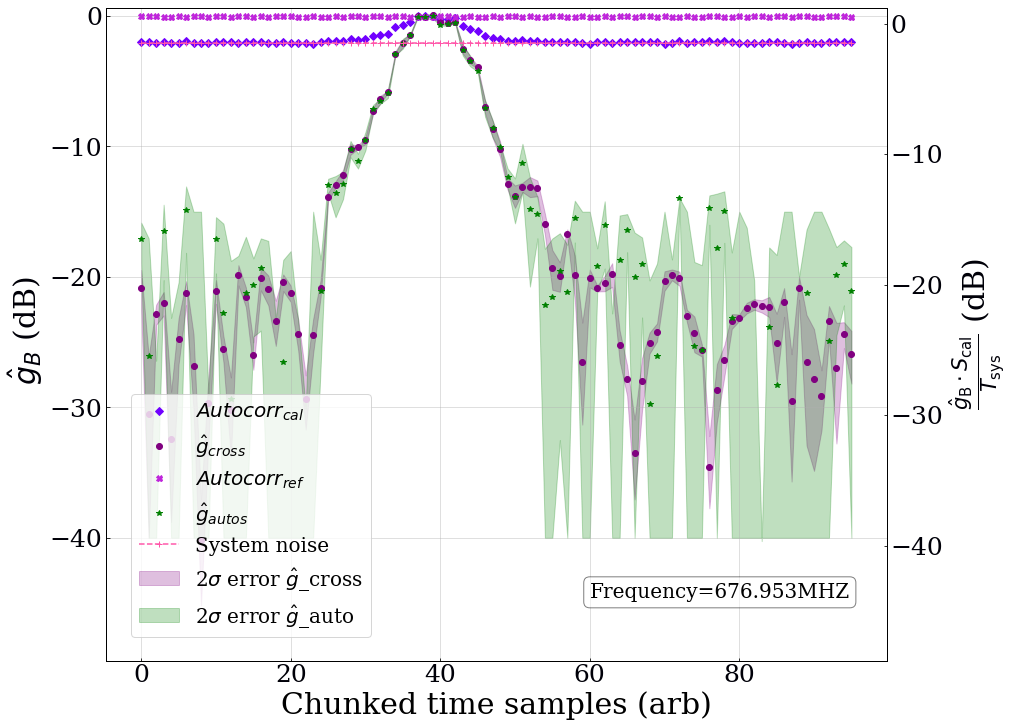

In [295]:
#Plotting beam pattern with correlator as well as vna data: 

colorsarr_=cm.gnuplot2(np.linspace(0,1,1024))
fig = plt.figure(figsize=[14,12])
ax1 = plt.subplot(111)
freq=400+((1024-f_ind)*0.390625)

##  plotting VNA data -- 
#angles1=np.arange(-140,130,10) ## x-range for VNA data 
#ax1.plot(angles1, list(reversed(s12mags)), ".", c=colorsarr[100], label='S12 from VNA')

## plotting normalized data -- 
t_samples=np.arange(0,96)
#angles_gauto = np.arange(-55,135,5) #offseting by few degress for better visualization
ax1.plot(t_samples, autolog_7x7, "D", c=colorsarr_[400], label='$Autocorr_{cal}$')
ax1.plot(t_samples, crosslog_7x9, "o",  c='purple',label='$\hat{g}_{cross}$')
ax1.plot(t_samples, autolog_9x9, "X", c=colorsarr_[500],label='$Autocorr_{ref}$')
ax1.plot(t_samples, g_autolog_7x7, "*", c='green',label='$\hat{g}_{autos}$')
ax1.plot(t_samples, autolog_7x7_off, "+--", c=colorsarr_[600], label='System noise')

#ax1.fill_between(t_samples, yerr_cross_lo, yerr_cross_hi, alpha=0.75, color='#E69F00', label='1$\sigma$ error $\hat{g}$_cross')
ax1.fill_between(t_samples, yerr_cross_lo2, yerr_cross_hi2, alpha=0.25, color='purple', label='2$\sigma$ error $\hat{g}$_cross')
#ax1.fill_between(t_samples, yerr_gauto_lo, yerr_gauto_hi, alpha=0.25, color='#E69F00', label='1$\sigma$ error $\hat{g}$_auto')
ax1.fill_between(t_samples, yerr_gauto_lo2, yerr_gauto_hi2, alpha=0.25, color='green', label='2$\sigma$ error $\hat{g}$_auto')

#ax1.axhline(y=-6.24, color='black', linestyle='--', linewidth=2)
#y=-6.24
#ax1.text(0.37, y, r"$1\%$ precision at $\hat{g}_B$=-6.24dB",transform=ax1.get_yaxis_transform(), ha='right', va='bottom', fontsize=20,color='black')
#ax1.set_xlabel("angle (deg)", fontsize=30)
ax1.set_xlabel("Chunked time samples (arb)", fontsize=30)
ax1.set_ylabel( " $\hat{g}_{B}$ (dB)", color=colorsarr_[10], fontsize=30)
ax1.tick_params(axis='both', labelcolor=colorsarr_[10], labelsize=25)
# adding these fractional offsets (which are highest gT_dB values) to align the values of g_auto and gT 
# and keep the range same for both axes
ax1.set_ylim(-25+0.5976954615354718-25,0+0.5976954615354718)
ax1.legend(fontsize=20, loc='lower left', bbox_to_anchor=(0.02, 0.02))

######-----------------------------##########

## plotting un-normalized data -- 
ax2 = ax1.twinx()
#ax2.plot(angles, gT_dB, "o", c=colorsarr_[700], label=r"$\hat{g}_{T} = \frac{\hat{g}_{\mathrm{B}} \cdot S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)")
ax2.set_ylabel(r"$\frac{\hat{g}_{\mathrm{B}} \cdot S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)", color=colorsarr_[10], fontsize=30)
ax2.tick_params(axis='both', labelcolor=colorsarr_[10], labelsize=25)
ax2.set_ylim(-25-25+(2*0.5976954615354718),0+(2*0.5976954615354718)) # adding these offsets to align the values of g_auto and gT and keep the range same for both axes  
ax2.grid(False)
ax2.text(60, -19-25, f"Frequency={freq:.3f}MHZ", # x, y in data coords
    fontsize=20, bbox=dict(boxstyle='round', #'round', 'square', 'round4', etc.
    facecolor='white', edgecolor='black', alpha=0.5))

plt.show()
#fig.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/publication_figures/beam_maps_2.5m_s/BeamMap_fbin{f_ind}.pdf', 
#            dpi=300)


In [ ]:
f_ind=315
on_avgs, on_stds, off_avgs, on_var, off_var=Calculate_Stats_DroneData(pow_mag,bgsub_powmag,inds_on,inds_off,inds_span,f_ind)

In [ ]:
autos77=np.array(on_avgs[0][:len(off_avgs[0])])
autos99=np.array(on_avgs[2][:len(off_avgs[0])])
crosses79=np.array(on_avgs[1][:len(off_avgs[0])])
var_auto77=np.array(on_var[0][:len(off_avgs[0])])
var_auto99=np.array(on_var[2][:len(off_avgs[0])])
stddev_cross79=np.array(on_stds[1][:len(off_avgs[0])])
autos77_off=np.array(off_avgs[0])
var_auto77_off=np.array(off_var[0])

In [265]:
"""
    For publication -- plotting all frequencies on same plot 
"""

def beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr):
    """Function to plot beam amplitude recovery (%):
    
    Parameters
    ----------
    
    avgs: averages of ON data points of individual correlator channels 
    avgs_off: averages of OFF data points of individual correlator channels
    stds: standard deviations of ON data points of individual correlator channels
    var: variances of ON data points of individual correlator channels
    var_off: variances of OFF data points of individual correlator channels
    """
    
    for index,f_ind in enumerate(freq_arr):
        
        #Loading stats from saved files:
        #avgs=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_fbin{f_ind}.npz")
        #avgs_off=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/means_off_fbin{f_ind}.npz")
        #stds=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/stds_fbin{f_ind}.npz")
        #var=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_fbin{f_ind}.npz")
        #var_off=np.load(f"/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/034Z...Mar192025/stats/var_off_fbin{f_ind}.npz")


        """stats from saved files -- N 65536 (steps of 5 degrees) (range -50 t0 130)
        autos and crosses means, std dev and variances lists -- correlator data 
        
        Parameters
        ----------

        autos_7x7 -- <VV*>t,ON
        autos_7x7_off -- <VV*>t,OFF
        crosses_7x9 -- <VtVref*>ON
        autos_9x9 -- <VV*>ref,ON 
        autos_9x9_off -- <VV*>ref,OFF (which is 0 in this case) 
        """
        
        freq=400+((1024-f_ind)*0.390625)

        # sqrt of total integration period -- N 65536
        stddev_cross7x9=stddev_cross79/2

        ## g_autos77 --  <VV*>t,ON - <VV*>t,OFF / <VV*>ref,ON - <VV*>ref,OFF -- N 65536 
        g_autos77 = (autos77 - autos77_off) / autos99

        """
            std dev using error propagation equation -- 
            -- to calculate variance and std dev of g_autos0x0 -- N 65536 
        """
        t11 = np.square(1/autos99) 
        t21 = np.square(1/autos99) 
        t31 = np.square((autos77-autos77_off)/(np.square(autos99))) 

        t12=var_auto77 
        t22=var_auto77_off 
        t32=var_auto99 

        t1, t2, t3 = t11*t12, t21*t22, t21*t22

        var_gauto77= t1 + t2 + t3 
        #std dev for single point and compensated for sims where 4*41.9xxms is int time
        stddev_gauto77=np.sqrt(var_gauto77)/2

        # error for crosses -- std/mean -- N 65536 
        err_crosses = []
        err_cross_percent = []
        for i in np.arange(0,np.size(stddev_cross7x9)):
            err = stddev_cross7x9[i]/crosses79[i]
            err_crosses.append(err)
            err_percent = (stddev_cross7x9[i]/crosses79[i])*100
            err_cross_percent.append(err_percent)

        # error for autos -- std/mean -- N 65536 
        err_autos = []
        err_auto_percent = []
        for i in np.arange(0,np.size(stddev_gauto77)):
            aerr = stddev_gauto77[i]/ g_autos77[i]
            err_autos.append(aerr)
            aerr_percent = (stddev_gauto77[i]/ g_autos77[i])*100
            err_auto_percent.append(aerr_percent)

        #gT= gBeam x Scal/Tsys =(Pon-Poff)/Poff where gBeam is always 1
        g_T = (autos77 - autos77_off) / autos77_off
        
        return err_auto_percent, err_cross_percent, g_T


In [274]:
#fitting function 
def fit_(x, A, k):
    return A/(x+k)

In [266]:
err_auto_percent, err_cross_percent, g_T=beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr)

In [267]:
errauto_f1= beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr=[315])[0]
errcross_f1= beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr=[315])[1]
gT_f1= beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr=[315])[2]
#errauto_f2= beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr=[325])[0]
#errcross_f2= beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr=[325])[1]
#gT_f2= beam_amp_recovery_pub(autos77,autos99,crosses79,var_auto77,var_auto99,stddev_cross79,autos77_off,var_auto77_off,freq_arr=[325])[2]

/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/3789116155.py:67: RuntimeWarning: invalid value encountered in log10
  ax2.plot(10*np.log10(gT_f1[20:50]), errauto_f1[20:50], 'D', c='blue', label=f'Autocorr-meas (Freq index = 600)')
/var/folders/g1/8y2gy6ys10d17y5j2rzwkwzc0000gn/T/ipykernel_48276/3789116155.py:68: RuntimeWarning: invalid value encountered in log10
  ax2.plot(10*np.log10(gT_f1[20:50]), errcross_f1[20:50], 'v', c='red', label=f'Crosscorr-meas (Freq index = 600)')


Fitted parameters for crosses: A = 0.210, k = 0.040


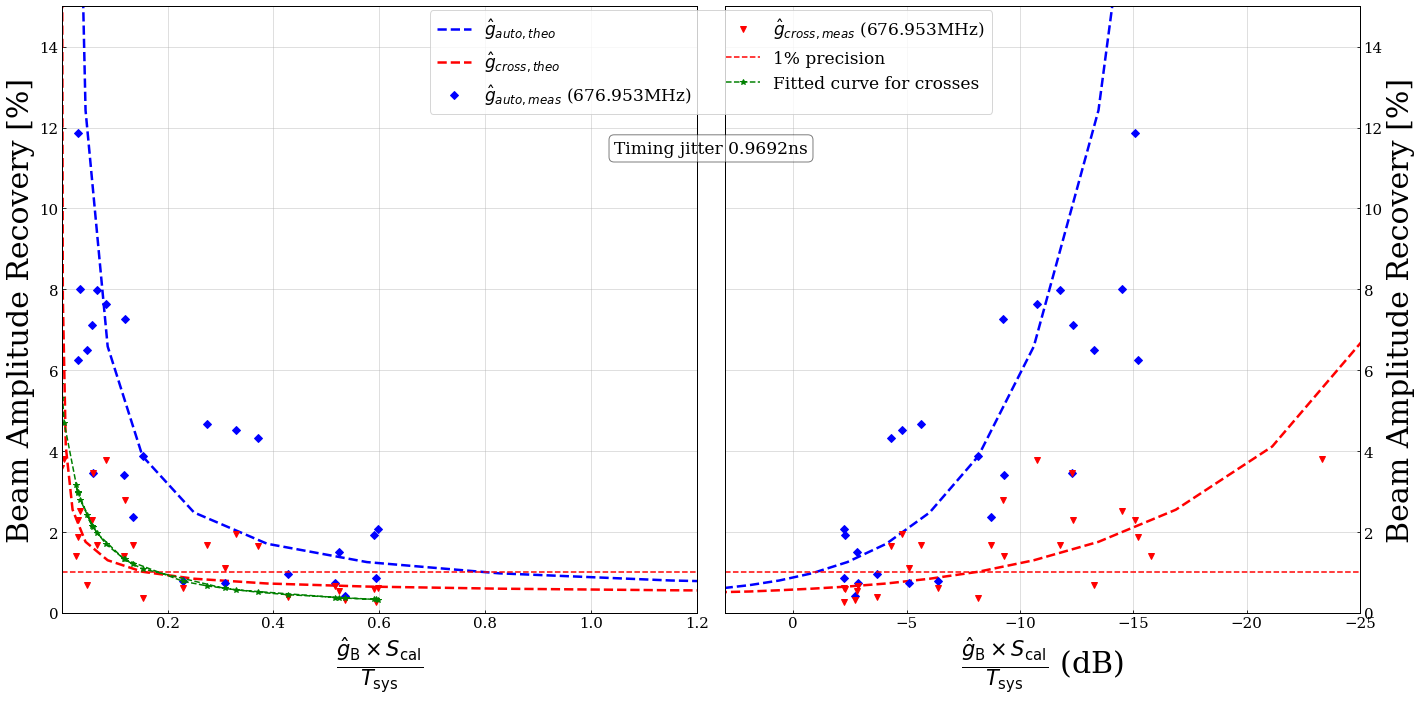

In [301]:
##dns simulations -- beam amplitude recovery in presence of timing noise 

fman=727e6 #select freq
t_length=65536 # 4*16384
inputpower=2**0 # this is 1
iteration_space=np.arange(10000) # total 10000 realizations 
jitter_space=np.hstack((np.array([0]),np.linspace(0.0e-9,1.4e-9,14))) # total 15 values 
#jitter_space=np.hstack((np.array([0]),np.linspace(1.4e-9,2.1e-9,8))) # total 9 values
gain_space=(np.linspace(0.05,1.2,15)**2.0) # total 30 values 

#Import a file -- loading saved data for (imapact of timing jitter) sims -- N 65536
dat=np.load("/Users/kalyanibhopi94/Documents/kalyanib_dns/beam_amp_recovery_timing0-1.4ns_10000.npz")
#Assign the variables:
input_phase=dat['input_phase']
q_sig_scaling=dat['q_sig_scaling']
q_corr_scaling=dat['q_corr_scaling']
nq_max_ind_auto=dat['nq_max_ind_auto']
nq_max_mag_auto_on=dat['nq_max_mag_auto_on']
nq_max_mag_auto_off=dat['nq_max_mag_auto_off']
nq_max_ind_cross=dat['nq_max_ind_cross']
nq_max_mag_cross_on=dat['nq_max_mag_cross_on']
nq_max_mag_cross_off=dat['nq_max_mag_cross_off']
q_max_ind_auto=dat['q_max_ind_auto']
q_max_mag_auto_on=dat['q_max_mag_auto_on']
q_max_mag_auto_off=dat['q_max_mag_auto_off']
q_max_ind_cross=dat['q_max_ind_cross']
q_max_mag_cross_on=dat['q_max_mag_cross_on']
q_max_mag_cross_off=dat['q_max_mag_cross_off']
#Close the file:
dat.close()

q_a_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for autos 
q_c_norm=np.zeros(q_max_mag_auto_on.shape) # normalization factor for crosses 
for j in range(len(jitter_space)):
    q_a_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*(q_corr_scaling[j,:,:]**2.0)*(t_length)*(np.outer((gain_space[:]**2.0),np.ones(len(iteration_space))))))
    q_c_norm[j,:,:]=(1.0/(2*(inputpower**2.0)*q_corr_scaling[j,:,:]*q_sig_scaling[j,:,:]*(t_length)*(np.outer((gain_space[:]**1.0),np.ones(len(iteration_space))))))

# q_x -- error on autos; q_y -- error on crosses; q_z -- error on phase 
q_x=100.0*np.nanstd((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)/np.nanmean((np.abs(q_a_norm*q_max_mag_auto_on[:,:,:])-np.abs(q_a_norm*q_max_mag_auto_off[:,:,:])),axis=2)
q_y=100.0*np.nanstd(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)/np.nanmean(np.abs(q_c_norm*q_max_mag_cross_on[:,:,:]),axis=2)
q_z=100.0*np.nanstd(-np.angle(nq_max_mag_cross_on[:,:,:]),axis=2)/(2.0*np.pi)

colorsarr=cm.gnuplot2(np.linspace(0,1,1024))
#fig = plt.figure(figsize=[11,9])
#ax = plt.subplot(111)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

##Theoretical curves --
ax1.plot(gain_space*gain_space,q_x[10,:],linestyle= '--',linewidth=2.5, c='blue',label=r'$\hat{g}_{auto,theo}$')
ax1.plot(gain_space*gain_space,q_y[10,:],linestyle= '--',linewidth=2.5, c='red',label=r'$\hat{g}_{cross,theo}$')

##Measured curves -- 
ax1.plot(gT_f1[20:50], errauto_f1[20:50], 'D', c='blue', label=r'$\hat{g}_{auto,meas}$ (676.953MHz)')
ax1.plot(gT_f1[20:50], errcross_f1[20:50], 'v', c='red', label=r'$\hat{g}_{cross,meas}$ (676.953MHz)')
ax1.axhline(y = 1, color = 'r', linestyle = '--', label= "1% precision")
ax1.set_ylim(0,15)
ax1.set_xlim(0.00025,1.2)
ax1.grid(True)
ax1.set_xlabel(r'$\frac{\hat{g}_{\mathrm{B}} \times S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$', fontsize= 30) 
ax1.set_ylabel('Beam Amplitude Recovery [%]', fontsize= 30)

##Theoretical curves in log space --
ax2.plot(10*np.log10(gain_space*gain_space),q_x[10,:],linestyle= '--',linewidth=2.5, c='blue',label='Autocorr-theo')
ax2.plot(10*np.log10(gain_space*gain_space),q_y[10,:],linestyle= '--',linewidth=2.5, c='red',label='Crosscorr-theo')

##Measured curves in log space -- 
ax2.plot(10*np.log10(gT_f1[20:50]), errauto_f1[20:50], 'D', c='blue', label=f'Autocorr-meas (Freq index = 600)')
ax2.plot(10*np.log10(gT_f1[20:50]), errcross_f1[20:50], 'v', c='red', label=f'Crosscorr-meas (Freq index = 600)')
plt.axhline(y = 1, color = 'r', linestyle = '--', label= "1% precision")
ax2.set_ylim(0,15)
ax2.set_xlim(-25,3)
ax2.grid(True)
ax2.set_xlabel(r'$\frac{\hat{g}_{\mathrm{B}} \times S_{\mathrm{cal}}}{T_{\mathrm{sys}}}$ (dB)', fontsize= 30) 
ax2.invert_xaxis()
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")
ax2.set_ylabel('Beam Amplitude Recovery [%]', fontsize= 30)

#performing fit on beam amp recovery errors: 

bounds = ([0,0], [np.inf, np.inf])
initial_params_crosses = [10,15]
#initial_params_autos = [10,15]
popt_cross, pcov_cross = curve_fit(fit_, gT_f1[20:50], errcross_f1[20:50], p0=initial_params_crosses, bounds=bounds, nan_policy='omit')
#popt_auto, pcov_auto = curve_fit(fit_, gT_f1[20:50], errauto_f1[20:50], p0=initial_params_crosses, bounds=bounds, nan_policy='omit')


#Extracting fitted parameters:
A_fit_cross, k_fit_cross = popt_cross
print(f"Fitted parameters for crosses: A = {A_fit_cross:.3f}, k = {k_fit_cross:.3f}")
#A_fit_auto, k_fit_auto = popt_auto
#print(f"Fitted parameters for crosses: A = {A_fit_auto:.3f}, k = {k_fit_auto:.3f}")

x_fit = gT_f1[20:50]
y_fit_cross = fit_(x_fit, *popt_cross)
#y_fit_auto = fit_(x_fit, *popt_auto)

ax1.plot(x_fit, y_fit_cross,'*--',c='green', label="Fitted curve for crosses")
#ax1.plot(x_fit, errcross_f1[20:50],'.',c='red', label="Fitted curve for crosses")
#ax1.plot(x_fit, y_fit_auto,'*--',c='blue', label="Fitted curve for autos")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 0.90), 
           ncol=2, fontsize=17)  # Adjust y-position as needed
fig.text(0.5, 0.78, f"Timing jitter {jitter_space[10]*(10**9):.4f}ns",
         ha='center', va='center', fontsize=17, bbox=dict(boxstyle='round', facecolor='white', 
        edgecolor='black', alpha=0.5))
fig.tight_layout()

fig.savefig('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr11...307Z/publication_figures/beam_amp_recovery_2.5m_s/beam_amp_recovery.png', 
            dpi=300)
plt.show()


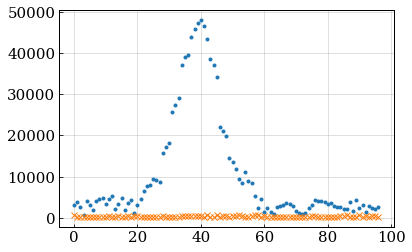

In [15]:
on_stds_cross=np.array(on_stds[1])/2 #integrating for 167.xx ms 
plt.plot(on_avgs[1],'.')
plt.plot(on_stds_cross,'x')
on_avgs_arr=np.array(on_avgs[1])
on_stds_arr=on_stds_cross
error=on_stds_arr/on_avgs_arr * 100

Text(0.5, 0, 'time samples')

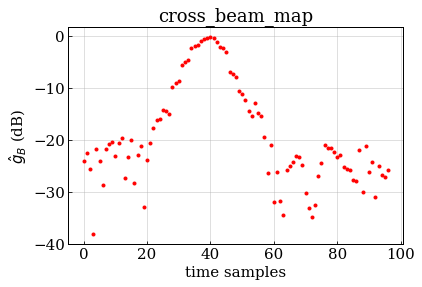

In [31]:
# crosses 1D slice
auto_ref_on=np.array(on_avgs[2])
crosses_on=np.array(on_avgs[1])
crosslog=20*np.log10(crosses_on/np.sqrt(auto_ref_on)) - 45.5
plt.plot(np.arange(0,97),crosslog, 'r.')
plt.title('cross_beam_map')
plt.ylabel('$\hat{g}_B$ (dB)')
plt.xlabel('time samples')

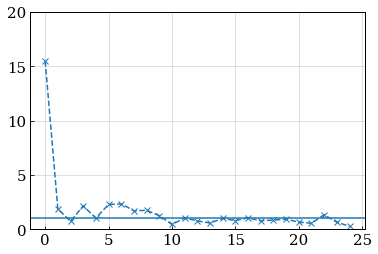

In [23]:
# error totally depends on how much data points I consider for 
error_mb=error[20:45]
plt.plot(error_mb,'x--') 
plt.ylim(0,20) 
plt.axhline(1)

In [24]:
#fitting function 
def fit_(x, A, k):
    return A/(x+k)

Fitted parameters for crosses: A = 4.640, k = 0.302


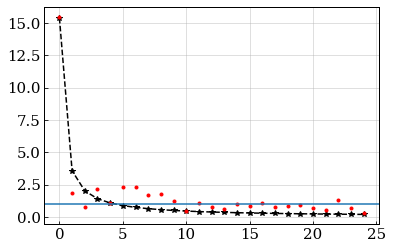

In [30]:
#performing fit on beam amp recovery errors: 

bounds = ([0,0], [np.inf, np.inf])
initial_params_crosses = [10,15]
#initial_params_autos = [1,0.001]
popt_cross, pcov_cross = curve_fit(fit_, np.arange(0,25), error_mb, p0=initial_params_crosses, bounds=bounds, nan_policy='omit')

#Extracting fitted parameters:
A_fit_cross, k_fit_cross = popt_cross
print(f"Fitted parameters for crosses: A = {A_fit_cross:.3f}, k = {k_fit_cross:.3f}")

x_fit = np.arange(0,25)
y_fit_cross = fit_(x_fit, *popt_cross)

plt.plot(x_fit, y_fit_cross,'*--',c='black', label="Fitted curve for crosses")
plt.plot(x_fit, error_mb,'.',c='red', label="Fitted curve for crosses")
plt.axhline(1)
#ax.plot(x_fit, y_fit_auto,'*--',c=colorsarr[200], label="Fitted curve for autos")

In [ ]:
## Background subtraction for crosses not required as crosses are already sky-free (uncorrelated sky due to crossing with ref channel)
def Perform_Background_Subtraction_Cross(self,inds_on,inds_off,inds_span,window_size=5):
        ## BACKGROUND SUBTRACTED SPECTRA: ##
        print("Calculating background spectra from indices where the noise source is off.")

        t_index_temp=np.union1d(inds_on, inds_span)
        t_index=np.union1d(t_index_temp,inds_off)
        
        V_bg=np.zeros(self.shape)
        V_bgsub=np.zeros(self.shape)
        #V_cross_bg=np.zeros(V_cross.shape).astype(complex)
        #V_cross_bgsub=np.zeros(V_cross.shape).astype(complex)
        
        ## Loop over all indices and construct the V_bg array:
        for k,ind in enumerate(t_index):
            ## If ind is an off spectra, use this off spectra for the background:
            if k in inds_off:
                V_bg[k,:,8]=self[k,:,8]
                #if self.crossmap!=None:
                #self.V_cross_bg[k,:,:]=self.V_cross[k,:,:]
            ## If ind is an on spectra, create an off spectra by averaging the before/after off spectra:
            elif k in t_index_temp:
                t_window=np.intersect1d(np.arange(k-window_size,k+window_size),inds_off)
                V_bg[k,:,8]=np.nanmean(self[t_window,:,7],axis=0)
                #self.V_cross_bg[k,:,:]=np.nanmean(self.V_cross[t_window,:,:],axis=0)
        V_bgsub=self[:,:,8]-V_bg[:,:,8]
        # self.V_cross_bgsub=self.V_cross-self.V_cross_bg
        print("  --> Background subtraction completed using window_size = {}".format(window_size))
        return V_bgsub

In [ ]:
## for cross channel background subtraction 
## Background subtraction for crosses not required as crosses are already sky-free (uncorrelated sky due to crossing with ref channel)

bgsub_powmag=Perform_Background_Subtraction_Cross(pow_mag[:,:,:], inds_on, inds_off, inds_span, window_size=8)
bgsub_powmag[inds_off,:]=np.subtract(bgsub_powmag[inds_off,:],np.nanmean(pow_mag[inds_off,325,7])) # raise to original background -- needed? 
bgsub_powmag=np.add(bgsub_powmag,np.nanmean(pow_mag[inds_off,325,7]))
plt.plot(inds_on,bgsub_powmag[inds_on,325], 'b.')